In [1]:
from datetime import datetime, timedelta
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
import pytz

# Tooling

In [2]:
import requests

def binance_data(symbol=None):
    base_url = "https://eapi.binance.com/eapi/v1/mark"
    params = {}
    if symbol:
        params['symbol'] = symbol

    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
    else:
        print(f"Error: Status code {response.status_code}")
        print(response.text)
        return None

    options = []
    for option in data:

        full_symbol = option['symbol']
        symbol = full_symbol.split('-')[0]

        if symbol != 'BTC':
            continue

        options.append(option)

    return options

def get_spot_price(underlying='BTCUSDT'):
    base_url = "https://eapi.binance.com/eapi/v1/index"
    params = {
        'underlying' : underlying,
    }

    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
    else:
        print(f"Error: Status code {response.status_code}")
        print(response.text)
        return None
    
    return data['indexPrice']

def get_open_interest(expiration, underlying='BTC'):
    params = {
        'underlyingAsset' : underlying,
        'expiration': expiration,
    }

    base_url = "https://eapi.binance.com/eapi/v1/openInterest"

    response = requests.get(base_url, params=params)
    if response.status_code == 200:
        data = response.json()
    else:
        print(f"Error: Status code {response.status_code}")
        print(response.text)
        return None

    return data

In [209]:
data = binance_data()
S0 = float(get_spot_price())

current_time =  datetime.now(pytz.timezone('US/Eastern'))

strikes = []
mark_IVs = []
ttes = []
mark_prices = []
open_interests = []
is_calls = []
bid_ivs = []
ask_ivs = []

open_interest_dict = {}
expiry_times = {}

for option in tqdm(binance_data()):
    full_symbol = option['symbol']
    symbol = full_symbol.split('-')[0]

    if symbol != 'BTC':
        continue

    expiration = full_symbol.split('-')[1]

    strike = int(full_symbol.split('-')[2])
    markIV = float(option['markIV'])

    year = expiration[:2]
    month = expiration[2:4]
    day = expiration[4:6]

    # convert to a datetime object
    expiration_date = datetime(int(year)+2000, int(month), int(day), 4, 0, 0, tzinfo=pytz.timezone('US/Eastern'))
    strike = float(full_symbol.split('-')[2])
    is_call = full_symbol.split('-')[3] == 'C'

    tte = (expiration_date - current_time).total_seconds() / 3600 / 24 / 365.25

    open_interest = open_interest_dict.get(full_symbol, None)
    if open_interest is None:
        interest_data = get_open_interest(expiration) 
        for opt in interest_data:
            symbol = opt['symbol']

            sumOpenInterest = opt['sumOpenInterest']
            open_interest_dict[symbol] = sumOpenInterest

        open_interest = open_interest_dict[full_symbol]

    mark_price = option['markPrice']
    mark_IV = option['markIV']

    strikes.append(strike)
    mark_IVs.append(mark_IV)
    ttes.append(tte)
    mark_prices.append(mark_price)
    open_interests.append(open_interest)
    is_calls.append(is_call)
    bid_ivs.append(option['bidIV'])
    ask_ivs.append(option['askIV'])

ttes = np.array(ttes).astype(float)
strikes = np.array(strikes).astype(float)
mark_IVs = np.array(mark_IVs).astype(float)
mark_prices = np.array(mark_prices).astype(float)
open_interests = np.array(open_interests).astype(float)
bid_ivs = np.array(bid_ivs).astype(float)
ask_ivs = np.array(ask_ivs).astype(float)

100%|██████████| 608/608 [00:02<00:00, 234.29it/s]


In [210]:
df = pd.DataFrame({'strike': strikes, 'IV': mark_IVs, 'tte': ttes, 'price': mark_prices, 'open_interest': open_interests, 'is_call': is_calls, 'bid_IV': bid_ivs, 'ask_IV': ask_ivs})
df.head()

,strike,IV,tte,price,open_interest,is_call,bid_IV,ask_IV
0,55000.0,1.2,0.005219,52055.2,1.38,True,6.000000e-07,-1.000000e-08
1,55000.0,1.2,0.005219,0.1,48.71,False,-1.000000e-08,4.410226e+00
2,30000.0,1.2,0.005219,77046.9,22.77,True,6.000000e-07,-1.000000e-08
3,30000.0,1.2,0.005219,0.1,100.24,False,-1.000000e-08,9.335675e+00
4,70000.0,1.2,0.005219,37060.2,0.04,True,6.000000e-07,-1.000000e-08


In [211]:
df['iv_spread'] = df['ask_IV'] - df['bid_IV']

In [212]:
filtered_df = df[df['iv_spread'] < 0.05]

In [213]:
# df = df[df['open_interest'] > 3]
df['log_moneyness'] = np.log(df['strike'] / S0)

In [214]:
import plotly.graph_objects as go

# Make sure these are 1D arrays or lists of equal length:
# ttes = [time to expiry values]
# strikes = [strike prices]
# mark_IVs = [implied volatilities]

fig = go.Figure(data=[go.Scatter3d(
    x=ttes,
    y=strikes,
    z=mark_IVs,
    mode='markers',
    marker=dict(
        size=4,
        color=mark_IVs,      # color by IV
        colorscale='Viridis',
        colorbar=dict(title='IV'),
        opacity=0.8
    )
)])

fig.update_layout(
    title='3D Scatter of Market Implied Volatilities',
    scene=dict(
        xaxis_title='Time to Expiry (TTE)',
        yaxis_title='Strike',
        zaxis_title='Implied Volatility'
    ),
    height=800,
    width=800
)

fig.show()


In [215]:
filtered_df = df[df['iv_spread'] < 0.05]
filtered_df['log_moneyness'] = np.log(filtered_df['strike'] / S0)

C:\Users\chris\AppData\Local\Temp\ipykernel_54424\2111594509.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [216]:
filtered_df = filtered_df[filtered_df['tte'] < 1/365.25]

filtered_df.head()

,strike,IV,tte,price,open_interest,is_call,bid_IV,ask_IV,iv_spread,log_moneyness
508,103000.0,0.411900,0.002481,4074.8,3.87,True,6.000000e-07,-1.000000e-08,-6.100000e-07,-0.038445
509,99000.0,0.601300,0.002481,8055.8,0.01,True,6.000000e-07,-1.000000e-08,-6.100000e-07,-0.078055
510,109000.0,0.351812,0.002481,139.9,49.22,True,3.518122e-01,3.559202e-01,4.107960e-03,0.018173
511,96000.0,0.647300,0.002481,11052.0,0.00,True,-1.000000e-08,-1.000000e-08,0.000000e+00,-0.108826
513,98000.0,0.628500,0.002481,9053.9,0.00,True,6.000000e-07,-1.000000e-08,-6.100000e-07,-0.088207


In [266]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
from functools import partial

# Define sigmoid function
def sigmoid(x, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

def vol_smile(k, b, c, atm_vol):
    return atm_vol + b * k + c * k**2

def fetch_0dte_vol_smile():
    df, S0 = get_data()

    df = df[df['ask_IV'] - df['bid_IV'] < 0.05] # iv spread filtering
    df = df[df['tte'] < 1/365] # filter for 0 DTE

    df['d2'] = (np.log(S0/df['strike']) - 0.5* (df['IV']**2 * df['tte'])) / (df['IV'] * np.sqrt(df['tte']))
    df['log_moneyness'] = np.log(df['strike'] / S0) / np.sqrt(df['tte'])

    filtered_df = df
    
    # Calculate ITM probability
    filtered_df['binary_price'] = np.where(
        filtered_df['is_call'],
        norm.cdf(filtered_df['d2']),     # Call option
        norm.cdf(filtered_df['d2'])     # Put option
    )

    # fit a sigmoid to the 0dte data
    x_data = filtered_df['d2']
    y_data = filtered_df['binary_price']
    tte = filtered_df['tte'].iloc[0]

    # Initial guess for parameters: k=1, x0=0
    p0 = [1, 0]

    # Curve fitting
    params, _ = curve_fit(sigmoid, x_data, y_data, p0)
    x0_fit, d_fit = params

    def simgoid_0dte_fit(k):
        return 1 / (1 + np.exp(-k * (x0_fit - d_fit)))
    
    # Now for vol smile
    # filter for near the money
    filtered_df = filtered_df[abs(filtered_df['log_moneyness']) < 0.5]
    filtered_df = filtered_df.groupby(['tte', 'strike'], as_index=False).mean()

    tte = filtered_df['tte'].iloc[0]
    ivs = filtered_df['IV']
    moneyness = filtered_df['log_moneyness']

    # find the atm vol
    idx_atm = np.argmin(np.abs(moneyness))  # index of closest to zero
    atm_vol = ivs.iloc[idx_atm]
    atm_vol_1hr = atm_vol * np.sqrt(tte*365)

    print(f'ATM Vol {tte*365.25*24:.2f}hrs: {atm_vol*100:.5f}%')
    print(f'ATM Vol 1hr: {atm_vol_1hr*100:.5f}%')

    # Partial function to fix atm_vol parameter
    fit_func = partial(vol_smile, atm_vol=atm_vol)

    # Now fit only b and c
    params, _ = curve_fit(fit_func, moneyness, ivs, p0=[0, 0])  # initial guess for b and c

    # Volatility function with skew & curvature
    def get_vol(m):
        return vol_smile(m, *params, atm_vol)

    def fitted_vol_smile(k):
        return atm_vol + params[0] * k + params[1] * k**2
    
    d2_data =  x_data
    binary_price_data = y_data

    moneyness_data = moneyness
    iv_data = ivs

    return fitted_vol_smile, simgoid_0dte_fit, d2_data, binary_price_data, moneyness_data, iv_data, moneyness, ivs, tte, atm_vol, atm_vol_1hr

In [267]:
fetch_0dte_vol_smile()

ATM Vol 17.35hrs: 35.31778%
ATM Vol 1hr: 30.01660%


(<function __main__.fetch_0dte_vol_smile.<locals>.fitted_vol_smile(k)>,
 <function __main__.fetch_0dte_vol_smile.<locals>.simgoid_0dte_fit(k)>,
 508    1.823238
 510   -1.169511
 511    3.673353
 513    2.979104
 515    1.952747
 518    1.691122
 522    1.366915
 525    1.952747
 526    0.965267
 527    0.461919
 528    2.005772
 529   -1.578731
 530    4.103416
 534    3.334956
 538   -0.691415
 539   -0.111756
 550   -0.105461
 582   -0.413330
 586   -0.949717
 587    0.196934
 592    1.182625
 593    0.727986
 594   -2.079097
 598    0.184265
 600   -1.854569
 605   -1.889537
 Name: d2, dtype: float64,
 508    0.965866
 510    0.121099
 511    0.999880
 513    0.998555
 515    0.974575
 518    0.954593
 522    0.914174
 525    0.974575
 526    0.832794
 527    0.677930
 528    0.977560
 529    0.057199
 530    0.999980
 534    0.999573
 538    0.244652
 539    0.455508
 550    0.458005
 582    0.339683
 586    0.171128
 587    0.578061
 592    0.881521
 593    0.766689
 594    0.018

In [221]:
from scipy.stats import norm

filtered_df['d2'] = (np.log(S0/filtered_df['strike']) - 0.5* (filtered_df['IV']**2 * filtered_df['tte'])) / (filtered_df['IV'] * np.sqrt(filtered_df['tte']))
filtered_df

# Calculate ITM probability
filtered_df['binary_price'] = np.where(
    filtered_df['is_call'],
    norm.cdf(filtered_df['d2']),     # Call option
    norm.cdf(filtered_df['d2'])     # Put option
)

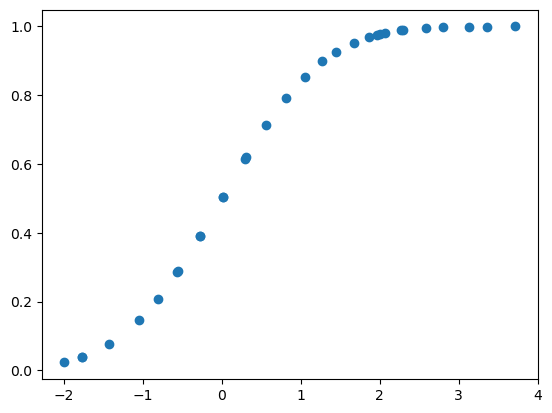

In [223]:
prices = filtered_df['binary_price']
d2 = filtered_df['d2']

plt.scatter(d2, prices)

ATM Vol: 32.65094% for next 21.75 hours
ATM Vol 1hr: 31.08339%


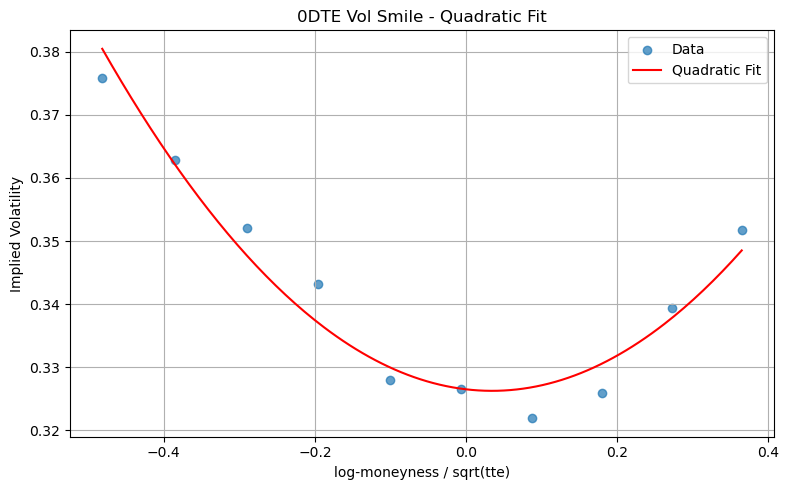

In [260]:
# 0dte vol smile
# filter for near the money
smile_df = filtered_df[abs(filtered_df['log_moneyness'])/np.sqrt(filtered_df['tte']) < 0.5]
smile_df = smile_df.groupby(['tte', 'strike'], as_index=False).mean()

log_moneyness = np.log(smile_df['strike'] / S0) / np.sqrt(smile_df['tte'])
ivs = smile_df['IV']

tte = smile_df['tte'].iloc[0]

x = log_moneyness
y = ivs

# Fit quadratic: y = a*x^2 + b*x + c
coeffs = np.polyfit(x, y, deg=2)
a, b, c = coeffs

# Create smooth curve for plotting
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = a * x_fit**2 + b * x_fit + c

atm_vol = c
print(f'ATM Vol: {atm_vol*100:.5f}% for next {tte*365.25*24:.2f} hours')
atm_vol_1hr = c * np.sqrt(tte*365.25)
print(f'ATM Vol 1hr: {atm_vol_1hr*100:.5f}%')

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='Data', alpha=0.7)
plt.plot(x_fit, y_fit, color='red', label='Quadratic Fit')
plt.xlabel('log-moneyness / sqrt(tte)')
plt.ylabel('Implied Volatility')
plt.title('0DTE Vol Smile - Quadratic Fit')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

R2: 0.99961
MAE: 0.64391 cents
Std MAE: 0.28335 cents


C:\Users\chris\AppData\Local\Temp\ipykernel_54424\3597478476.py:20: OptimizeWarning:

Covariance of the parameters could not be estimated



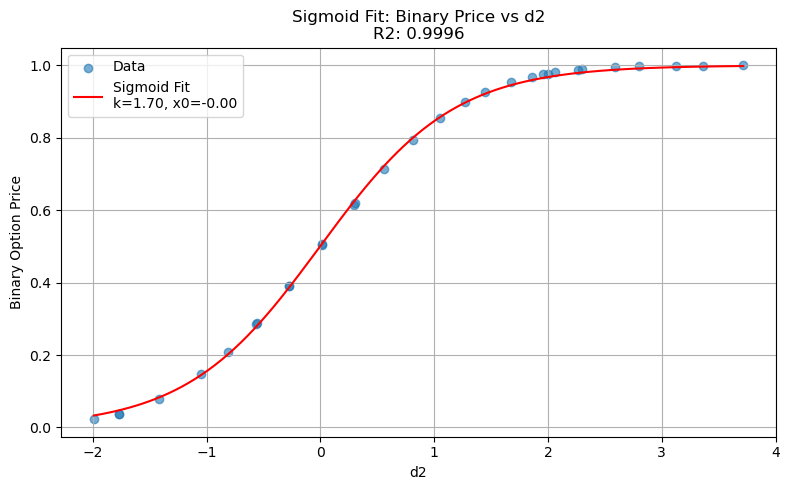

In [254]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm


# Your data
x_data = filtered_df['d2']
y_data = filtered_df['binary_price']
tte = filtered_df['tte'].iloc[0]

# Define sigmoid function
def sigmoid(x, k, x0, d):
    return 1 / (1 + np.exp(-k * (x - x0)))

# Initial guess for parameters: k=1, x0=0
p0 = [1, 0, 0]

# Curve fitting
params, _ = curve_fit(sigmoid, x_data, y_data, p0)
k_fit, x0_fit, d_fit = params

# Generate smooth x range for fitted curve
x_fit = np.linspace(x_data.min(), x_data.max(), 200)
y_fit = sigmoid(x_fit, k_fit, x0_fit, d_fit)
y_pred = sigmoid(x_data, k_fit, x0_fit, d_fit)  

r2 = 1 - np.sum((y_data - y_pred)**2) / np.sum((y_data - y_data.mean())**2)
mae = np.mean(np.abs(y_data - y_pred))
std_mae = np.std(np.abs(y_data - y_pred))
print(f'R2: {r2:.5f}')
print(f'MAE: {mae*100:.5f} cents')
print(f'Std MAE: {std_mae*100:.5f} cents')

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(x_data, y_data, alpha=0.6, label='Data')
plt.plot(x_fit, y_fit, color='red', label=f'Sigmoid Fit\nk={k_fit:.2f}, x0={x0_fit:.2f}')
plt.xlabel('d2')
plt.ylabel('Binary Option Price')
plt.title(f'Sigmoid Fit: Binary Price vs d2\nR2: {r2:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Maturity: 2.1621199622916665 days, MSE: 0.000012, R^2: 0.970211
Parameter a: 0.322967
Parameter b: -0.039205
Parameter c: 0.169050


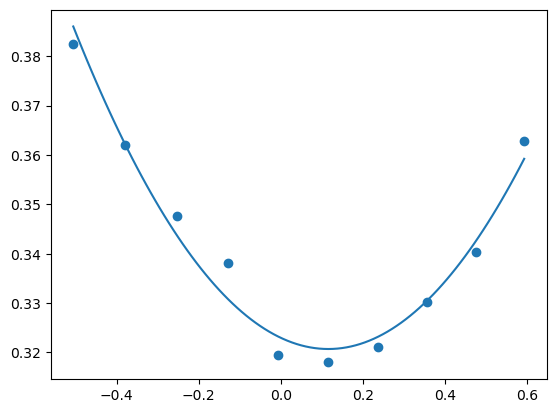

Maturity: 9.162119962291667 days, MSE: 0.000002, R^2: 0.973971
Parameter a: 0.343447
Parameter b: -0.043937
Parameter c: 0.204474


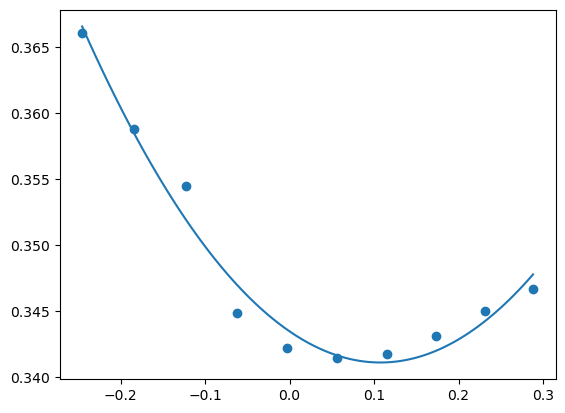

Maturity: 16.162119962291666 days, MSE: 0.000000, R^2: 0.980850
Parameter a: 0.355636
Parameter b: -0.026567
Parameter c: 0.139576


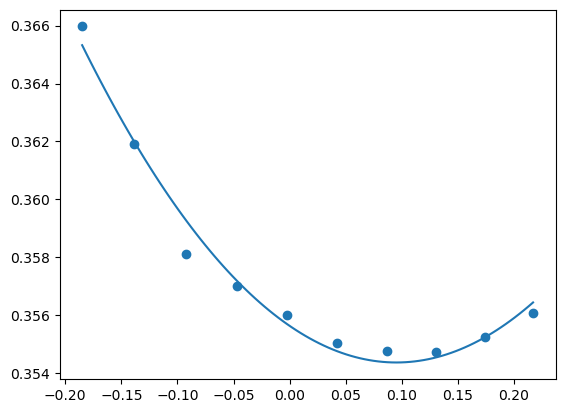

Maturity: 0.16211996229166667 days, MSE: 0.000090, R^2: 0.990994
Parameter a: 0.290327
Parameter b: -0.009002
Parameter c: 0.089828


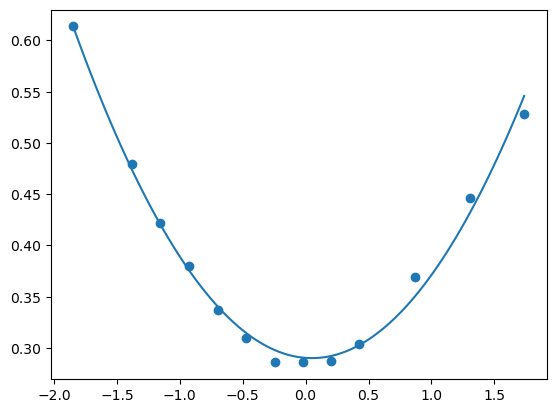

Maturity: 1.1621199622916667 days, MSE: 0.000014, R^2: 0.984527
Parameter a: 0.318372
Parameter b: -0.022056
Parameter c: 0.164790


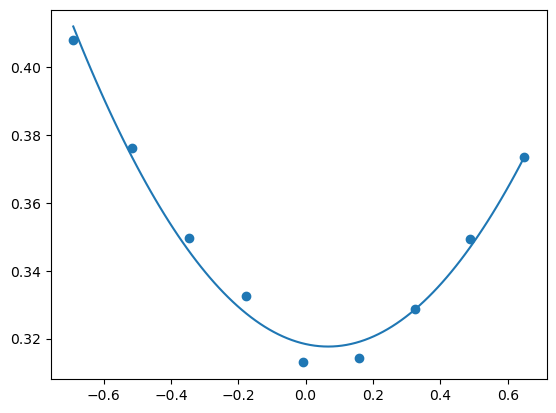

In [326]:
import numpy as np
from scipy.optimize import curve_fit

# Define quadratic smile function
def vol_smile(x, a, b, c):
    return a + b * x + c * x**2

a_params = []
b_params = []
c_params = []
Ts = []

for tte in filtered_df['tte'].unique():
    days_threshold = 30

    if tte > 1/365.25 * days_threshold:
        continue

    maturity_df = df[df['tte'] == tte]
    maturity_df = maturity_df[maturity_df['IV'] < 1.0]

    # filter for strikes within 2500 dollars of spot
    maturity_df = maturity_df[abs(maturity_df['strike'] - S0) < 5000]

    # average the calls and puts with same strike and expiry
    # maturity_df = maturity_df.groupby(['strike', 'tte']).mean().reset_index()
    maturity_df = maturity_df[maturity_df['is_call']]

    ivs = maturity_df['IV']
    moneyness = maturity_df['log_moneyness'] / np.sqrt(tte)

    # Fit curve
    params, _ = curve_fit(vol_smile, moneyness, ivs)

    # Volatility function with skew & curvature
    def get_vol(m):
        return vol_smile(m, *params)

    x_fit = np.linspace(min(moneyness), max(moneyness), 100)
    y_fit = get_vol(x_fit)

    mse = np.mean((get_vol(moneyness) - ivs) ** 2)
    r2 = 1 - mse / np.var(ivs)
    print(f"Maturity: {tte*365.25} days, MSE: {mse:.6f}, R^2: {r2:.6f}")
    
    a_params.append(params[0])
    b_params.append(params[1])
    c_params.append(params[2])
    Ts.append(tte)

    for i, param in enumerate(['a', 'b', 'c']):
        print(f"Parameter {param}: {params[i]:.6f}")

    # plot the vol smile
    plt.scatter(moneyness, ivs)
    plt.plot(x_fit, y_fit)
    plt.show()


In [172]:
from scipy.stats import linregress

params = pd.DataFrame({'a': a_params, 'b': b_params, 'c': c_params, 'T': Ts})
# sort by T
params = params.sort_values(by='T')
params.head()

# plot sqrt(T) vs a
T = params['T']
A = params['a']
B = params['b']
C = params['c']

T_fit = np.linspace(0, max(T), 100)

def power_law_fit_and_plot(ax, T, Y, label, is_negative=False):

    Y_fit_data = -Y if is_negative else Y  # Make positive if negative skew

    # Linearize: log(Y) = log(a) + beta * log(T)
    log_T = np.log(T)
    if is_negative:
        log_Y = np.log(abs(Y))
    else:
        log_Y = np.log(Y)

    # Perform linear regression on log-log scale
    slope, intercept, r_value, p_value, std_err = linregress(log_T, log_Y)
    beta = slope
    a = np.exp(intercept)

    # Predicted Y using fitted power law
    T_fit = np.linspace(min(T), max(T), 100)
    Y_fit = a * T_fit**beta
    if is_negative:
        Y_fit = -Y_fit  # Flip back for plotting

    # Plot
    if label == 'A':
        name = 'ATM Vol'
    elif label == 'B':
        name = 'Skew'
    elif label == 'C':
        name = 'Curvature'

    ax.scatter(T, Y, label='Data')
    ax.plot(T_fit, Y_fit, 'r-', label=f'Fit: a*T^{beta:.2f}')
    ax.set_title(f'{name} vs T\n$R^2$={r_value**2:.3f}, p={p_value:.3g}')
    ax.set_xlabel('T')
    ax.set_ylabel(label)
    ax.legend()

    return a, beta

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Plot each parameter
a_A, beta_A = power_law_fit_and_plot(axs[0], T, A, 'A')
a_B, beta_B = power_law_fit_and_plot(axs[1], T, B, 'B', is_negative=True)
a_C, beta_C = power_law_fit_and_plot(axs[2], T, C, 'C')
plt.show()

def get_params(T_new):
    """
    Return (A, B, C) for a given T using power law fits.
    """
    A_new = a_A * T_new**beta_A
    B_new = a_B * T_new**beta_B
    C_new = a_C * T_new**beta_C
    return A_new, B_new, C_new

def calibrated_vol_smile(T, k):
    a, b, c = get_params(T)
    return a + b * k + c * k**2

import plotly.graph_objects as go

min_time = 240 # in minutes
min_time = min_time / 60 / 24 / 365.25 # in days

T = np.linspace(min_time, max(T), 100)
k = np.linspace(-1, 1, 100)

T_grid, k_grid = np.meshgrid(T, k)
IV_surface = calibrated_vol_smile(T_grid, k_grid)

# Create 3D surface plot
fig = go.Figure(data=[go.Surface(
    z=IV_surface*100,
    x=T_grid,
    y=k_grid,
    colorscale='Viridis',
    colorbar=dict(title='IV'),
)])

fig.update_layout(
    title='Calibrated Volatility Smile Surface',
    scene=dict(
        xaxis_title='Time to Expiry (T)',
        yaxis_title='Log-Moneyness (k)',
        zaxis_title='Implied Volatility (%)',
    ),
    height=600,
    width=800
)

fig.show()


NameError: name 'a_params' is not defined

In [177]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress
import plotly.graph_objects as go
from scipy.interpolate import griddata
from scipy.interpolate import Rbf

import pytz
from functools import partial

# Quadtratic fitting

In [201]:
def get_data(symbol='BTC'):
    S0 = float(get_spot_price())

    current_time =  datetime.now(pytz.timezone('US/Eastern'))

    strikes = []
    mark_IVs = []
    ttes = []
    mark_prices = []
    open_interests = []
    is_calls = []
    bid_ivs = []
    ask_ivs = []

    open_interest_dict = {}
    expiry_times = {}

    for option in binance_data():
        full_symbol = option['symbol']
        symbol = full_symbol.split('-')[0]

        if symbol != 'BTC':
            continue

        expiration = full_symbol.split('-')[1]

        strike = int(full_symbol.split('-')[2])
        markIV = float(option['markIV'])

        year = expiration[:2]
        month = expiration[2:4]
        day = expiration[4:6]

        # convert to a datetime object
        expiration_date = datetime(int(year)+2000, int(month), int(day), 4, 0, 0, tzinfo=pytz.timezone('US/Eastern'))
        strike = float(full_symbol.split('-')[2])
        is_call = full_symbol.split('-')[3] == 'C'

        tte = (expiration_date - current_time).total_seconds() / 3600 / 24 / 365.25

        open_interest = open_interest_dict.get(full_symbol, None)
        if open_interest is None:
            interest_data = get_open_interest(expiration) 
            for opt in interest_data:
                symbol = opt['symbol']

                sumOpenInterest = opt['sumOpenInterest']
                open_interest_dict[symbol] = sumOpenInterest

            open_interest = open_interest_dict[full_symbol]

        mark_price = option['markPrice']
        mark_IV = option['markIV']

        strikes.append(strike)
        mark_IVs.append(mark_IV)
        ttes.append(tte)
        mark_prices.append(mark_price)
        open_interests.append(open_interest)
        is_calls.append(is_call)
        bid_ivs.append(option['bidIV'])
        ask_ivs.append(option['askIV'])

    ttes = np.array(ttes).astype(float)
    strikes = np.array(strikes).astype(float)
    mark_IVs = np.array(mark_IVs).astype(float)
    mark_prices = np.array(mark_prices).astype(float)
    open_interests = np.array(open_interests).astype(float)
    bid_ivs = np.array(bid_ivs).astype(float)
    ask_ivs = np.array(ask_ivs).astype(float)

    df = pd.DataFrame({'strike': strikes, 'IV': mark_IVs, 'tte': ttes, 'price': mark_prices, 'open_interest': open_interests, 'is_call': is_calls, 'bid_IV': bid_ivs, 'ask_IV': ask_ivs})

    return df, S0

def filter_df(df, S0, min_iv_spread=0.05):
    df['iv_spread'] = df['ask_IV'] - df['bid_IV']
    df = df[df['iv_spread'] < min_iv_spread]
    df['log_moneyness'] = np.log(df['strike'] / S0)
    return df

def vol_smile(k, b, c, atm_vol):
    return atm_vol + b * k + c * k**2

def fit_volsmile_params_from_market(df, days_threshold=30, price_threshold=5000, iv_threshold=1.0):
    a_params = []
    b_params = []
    c_params = []
    Ts = []

    valid_ttes = []

    for tte in df['tte'].unique():
        if tte > 1/365.25 * days_threshold:
            continue
        valid_ttes.append(tte)

    dfs = []

    plt.figure(figsize=(3*len(valid_ttes), 3))
    for i, tte in enumerate(valid_ttes):
        maturity_df = df[df['tte'] == tte]
        maturity_df = maturity_df[maturity_df['IV'] < iv_threshold]

        # filter for strikes within 2500 dollars of spot
        maturity_df = maturity_df[abs(maturity_df['strike'] - S0) < price_threshold]

        # average the calls and puts with same strike and expiry
        # maturity_df = maturity_df.groupby(['strike', 'tte']).mean().reset_index()
        maturity_df = maturity_df[maturity_df['is_call']]

        ivs = maturity_df['IV']
        moneyness = maturity_df['log_moneyness'] / np.sqrt(tte)

        # find the atm vol
        idx_atm = np.argmin(np.abs(moneyness))  # index of closest to zero
        atm_vol = ivs.iloc[idx_atm]

        # Partial function to fix atm_vol parameter
        fit_func = partial(vol_smile, atm_vol=atm_vol)

        # Now fit only b and c
        params, _ = curve_fit(fit_func, moneyness, ivs, p0=[0, 0])  # initial guess for b and c

        # Volatility function with skew & curvature
        def get_vol(m):
            return vol_smile(m, *params, atm_vol)

        x_fit = np.linspace(min(moneyness), max(moneyness), 100)
        y_fit = get_vol(x_fit)

        mse = np.mean((get_vol(moneyness) - ivs) ** 2)
        r2 = 1 - mse / np.var(ivs)
        # print(f"Maturity: {tte*365.25} days, MSE: {mse:.6f}, R^2: {r2:.6f}")

        print(atm_vol, params)
        
        a_params.append(atm_vol)
        b_params.append(params[0])
        c_params.append(params[1])
        Ts.append(tte)

        # for i, param in enumerate(['a', 'b', 'c']):
        #     print(f"Parameter {param}: {params[i]:.6f}")

        # plot the vol smile
        dfs.append(maturity_df)
        plt.subplot(1, len(valid_ttes), i+1)
        plt.scatter(moneyness, ivs)
        plt.plot(x_fit, y_fit)
        plt.title(f"Maturity: {tte*365.25:.1f} days, R^2: {r2:.4f}")
        plt.xlabel('Log-Moneyness/Sqrt(T)')
        plt.ylabel('IV')
    
    plt.tight_layout()
    plt.show()

    return a_params, b_params, c_params, Ts, dfs

def power_law_fit_and_plot(ax, T, Y, label, T_fit, is_negative=False):

    # Linearize: log(Y) = log(a) + beta * log(T)
    log_T = np.log(T)
    if is_negative:
        log_Y = np.log(abs(Y))
    else:
        log_Y = np.log(Y)

    # Perform linear regression on log-log scale
    slope, intercept, r_value, p_value, std_err = linregress(log_T, log_Y)
    beta = slope
    a = np.exp(intercept)

    # Predicted Y using fitted power law
    T_fit = np.linspace(min(T), max(T), 100)
    Y_fit = a * T_fit**beta
    if is_negative:
        Y_fit = -Y_fit  # Flip back for plotting

    # Plot
    if label == 'A':
        name = 'ATM Vol'
    elif label == 'B':
        name = 'Skew'
    elif label == 'C':
        name = 'Curvature'

    ax.scatter(T, Y, label='Data')
    ax.plot(T_fit, Y_fit, 'r-', label=f'Fit: a*T^{beta:.2f}')
    ax.set_title(f'{name} vs T\n$R^2$={r_value**2:.3f}, p={p_value:.3g}')
    ax.set_xlabel('T')
    ax.set_ylabel(label)
    ax.legend()

    return a, beta

def make_vol_surface(a_params, b_params, c_params, Ts, maturity_df, min_scale_time=60):
    Ts = np.array(Ts)
    A = np.array(a_params)
    B = np.array(b_params)
    C = np.array(c_params)
    T_fit = np.linspace(0, max(Ts), 100)

    # Create subplots

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    # Plot each parameter
    a_A, beta_A = power_law_fit_and_plot(axs[0], Ts, A, 'A', T_fit)
    a_B, beta_B = power_law_fit_and_plot(axs[1], Ts, B, 'B', T_fit, is_negative=True)
    a_C, beta_C = power_law_fit_and_plot(axs[2], Ts, C, 'C', T_fit)
    
    plt.tight_layout()
    plt.show()

    def get_params(T_new):
        """
        Return (A, B, C) for a given T using power law fits.
        """
        A_new = a_A * T_new**beta_A
        B_new = a_B * T_new**beta_B
        C_new = a_C * T_new**beta_C
        return A_new, B_new, C_new

    def calibrated_vol_smile(tau, k):
        a, b, c = get_params(tau)
        log_moneyness = k / np.sqrt(tau)
        return np.clip(a + b * log_moneyness + c * log_moneyness**2, 0, 0.7)

    # scale until some point
    min_scale_time = 240 # in minutes
    min_time = min_scale_time / 60 / 24 / 365.25 # in days

    T = np.linspace(min_time, max(Ts), 100)
    k_line = np.linspace(-0.05, 0.05, 100)

    T_grid, k_grid = np.meshgrid(T, k_line)
    IV_surface = calibrated_vol_smile(T_grid, k_grid)

    # calibrated surface
    surface = go.Surface(
        z=IV_surface * 100,
        x=T_grid * 365.25 * 24,  # Convert to hours
        y=k_grid,
        colorscale='Viridis',
        colorbar=dict(title='IV'),
        opacity=0.5
    )
    
    all_points = []
    for df in maturity_df:
        points = go.Scatter3d(
            x=df['tte'] * 365.25 * 24,
            y=df['log_moneyness'],
            z=df['IV'] * 100,
            mode='markers',
            marker=dict(color='red', size=4),
        )
        all_points.append(points)

    plots = [surface] + all_points
    fig = go.Figure(data=plots)

    fig.update_layout(
        title='Calibrated Volatility Smile Surface',
        scene=dict(
            xaxis_title='Hours to Expiry (T)',
            yaxis_title='Log-Moneyness (k)',
            zaxis_title='Implied Volatility (%)',
        ),
        height=600,
        width=800
    )

    fig.show()

    return get_params, calibrated_vol_smile

def analyze_vol_smile(df, S0,days_threshold=30, min_scale_time=120, min_iv_spread=0.05, price_threshold=5000, iv_threshold=1.0):
    filtered = filter_df(df, S0, min_iv_spread) # add filter controls
    
    atm_vol_params, skew_params, curvature_params, Ts, maturity_df = fit_volsmile_params_from_market(filtered, days_threshold, price_threshold, iv_threshold)
    get_params, calibrated_vol_smile = make_vol_surface(atm_vol_params, skew_params, curvature_params, Ts, maturity_df, min_scale_time)

    return get_params, calibrated_vol_smile

In [188]:
df, S0 = get_data()

C:\Users\chris\AppData\Local\Temp\ipykernel_54424\1775448450.py:111: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



0.32079577 [-0.01125142  0.19917068]
0.33164501 [-0.01387964  0.20718974]
0.32744408 [-0.00049497  0.17652568]
0.32008946 [-0.03194108  0.29007081]


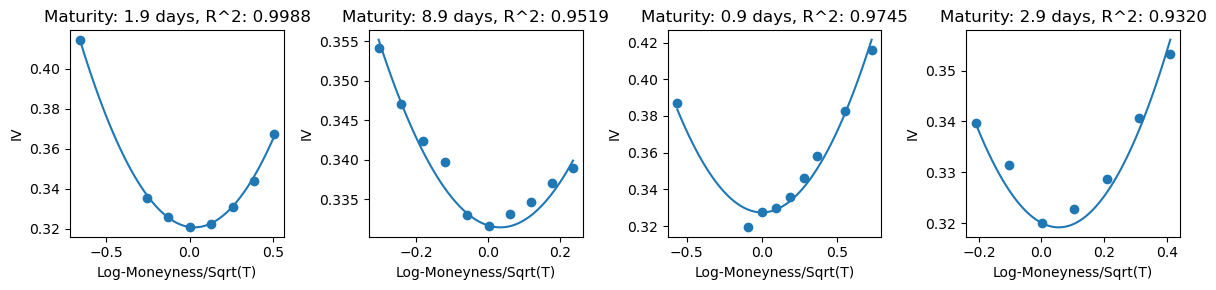

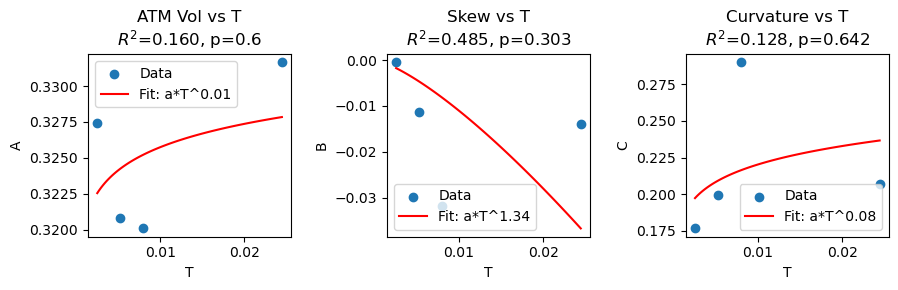

(<function __main__.make_vol_surface.<locals>.get_params(T_new)>,
 <function __main__.make_vol_surface.<locals>.calibrated_vol_smile(tau, k)>)

In [205]:
analyze_vol_smile(df, S0, days_threshold=9, min_scale_time=120)

In [150]:
from scipy import stats

In [206]:
# SVI model function
def svi_total_var(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

# Modified SVI loss and fit_svi to anchor at ATM point
def svi_loss_anchor(params, k, total_var, k0, w0, factor):
    b, rho, m, sigma = params
    # Compute a so that SVI passes through (k0, w0)
    a = w0 - b * (rho * (k0 - m) + np.sqrt((k0 - m)**2 + sigma**2))
    if b <= 0 or sigma <= 0 or abs(rho) >= 1:
        return np.inf  # Constraint violation
    model_var = svi_total_var(k, a, b, rho, m, sigma)

    # add a penalty for large rho
    epsilon = 1e-6
    rho_penalty = factor * 1 / (1-rho**2 + epsilon)
    return np.sum((model_var - total_var)**2) + rho_penalty

def fit_svi_anchor_multi_start(k, iv, tte, k0, w0, n_trials=100, rho_factor=1):
    total_var = (iv ** 2) * tte
    best_loss = np.inf
    best_params = None
    
    bounds = [(1e-5, 20), (-0.95, 0.95), (-6, 6), (1e-5, 100)]  # bounds for b, rho, m, sigma
    
    for _ in range(n_trials):
        # Random initial guess within bounds
        initial = [
            np.random.uniform(bounds[0][0], bounds[0][1]),  # b
            np.random.uniform(bounds[1][0], bounds[1][1]),  # rho
            np.random.uniform(bounds[2][0], bounds[2][1]),  # m
            np.random.uniform(bounds[3][0], bounds[3][1])   # sigma
        ]
        
        result = minimize(
            svi_loss_anchor,
            initial,
            args=(k, total_var, k0, w0, rho_factor),
            method='L-BFGS-B',
            bounds=bounds
        )
        
        if result.success and result.fun < best_loss:
            best_loss = result.fun
            b, rho, m, sigma = result.x
            a = w0 - b * (rho * (k0 - m) + np.sqrt((k0 - m)**2 + sigma**2))
            best_params = [a, b, rho, m, sigma]
    
    return best_params

# Update analyze_vol_smile_SVI to use ATM anchoring


def calculate_p_value(observed, fitted, n_params=5):
    """
    Calculate p-value for the fit using F-test.
    observed: observed values
    fitted: fitted values
    n_params: number of parameters in the model (5 for SVI)
    """
    n = len(observed)
    if n <= n_params:
        return 1.0  # Not enough data points
    
    # Calculate residuals
    residuals = observed - fitted
    
    # Calculate degrees of freedom
    df_model = n_params - 1  # -1 for the constant term
    df_residual = n - n_params
    
    # Calculate F-statistic
    ss_residual = np.sum(residuals**2)
    ss_total = np.sum((observed - np.mean(observed))**2)
    ss_model = ss_total - ss_residual
    
    if ss_residual == 0:
        return 0.0  # Perfect fit
    
    f_stat = (ss_model / df_model) / (ss_residual / df_residual)
    
    # Calculate p-value
    p_value = 1 - stats.f.cdf(f_stat, df_model, df_residual)
    
    return p_value

def analyze_vol_smile_SVI(df, S0, days_threshold=30, min_iv_spread=0.05, price_threshold=5000, iv_threshold=1.0,rho_penalty=1):
    filtered = filter_df(df, S0, min_iv_spread)
    filtered = filtered[filtered['IV'] < iv_threshold]
    filtered = filtered[np.abs(filtered['strike'] - S0) < price_threshold]

    svi_params = []
    Ts = []
    maturity_dfs = []

    unique_ttes = np.sort(filtered['tte'].unique())
    valid_ttes = [tte for tte in unique_ttes if tte * 365.25 <= days_threshold]

    plt.figure(figsize=(3*len(valid_ttes), 3))

    for i, tte in enumerate(valid_ttes):
        maturity_df = filtered[filtered['tte'] == tte]
        if len(maturity_df) < 5:
            continue
        # maturity_df = maturity_df[maturity_df['is_call']]
        k = maturity_df['log_moneyness'].values
        iv = maturity_df['IV'].values
        t = tte
        total_var = (iv ** 2) * t
        # Find ATM point (closest to k=0)
        atm_idx = np.argmin(np.abs(k))
        k0 = k[atm_idx]
        w0 = total_var[atm_idx]
        # Fit SVI with ATM anchoring
        params = fit_svi_anchor_multi_start(k, iv, t, k0, w0, 100, rho_penalty)
        if params is None:
            continue
        svi_params.append(params)
        Ts.append(tte)
        maturity_dfs.append(maturity_df)
        # Calculate fitted total variance and R^2
        fitted_total_var = svi_total_var(k, *params)
        r2 = 1 - np.sum((fitted_total_var - total_var)**2) / np.sum((total_var - np.mean(total_var))**2)

        # Plot
        k_fit = np.linspace(min(k), max(k), 100)
        svi_fit = np.sqrt(np.maximum(svi_total_var(k_fit, *params) / t, 0))
        plt.subplot(1, len(valid_ttes), i+1)
        plt.scatter(k, iv, label='Market IV')
        plt.plot(k_fit, svi_fit, 'r-', label='SVI fit')
        plt.title(f"TTE: {tte*365.25:.1f}d, $R^2$={r2:.3f}")
        plt.xlabel('Log(K/S0)')
        plt.ylabel('IV')
        plt.legend()

    plt.tight_layout()
    plt.show()
    return svi_params, Ts, maturity_dfs

def plot_svi_params_vs_time(svi_params, Ts):
    """
    Plot how each SVI parameter varies with time to expiry.
    svi_params: list of [a, b, rho, m, sigma] for each maturity
    Ts: list of time to expiry (in years) for each maturity
    """
    svi_params = np.array(svi_params)
    Ts = np.array(Ts)
    param_names = ['a', 'b', 'rho', 'm', 'sigma']
    plt.figure(figsize=(15, 8))
    for i, name in enumerate(param_names):
        plt.subplot(2, 3, i+1)
        plt.plot(Ts * 365.25, svi_params[:, i], marker='o')
        plt.xlabel('Time to Expiry (days)')
        plt.ylabel(name)
        plt.title(f'SVI parameter {name} vs Time to Expiry')
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_54424\1775448450.py:111: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



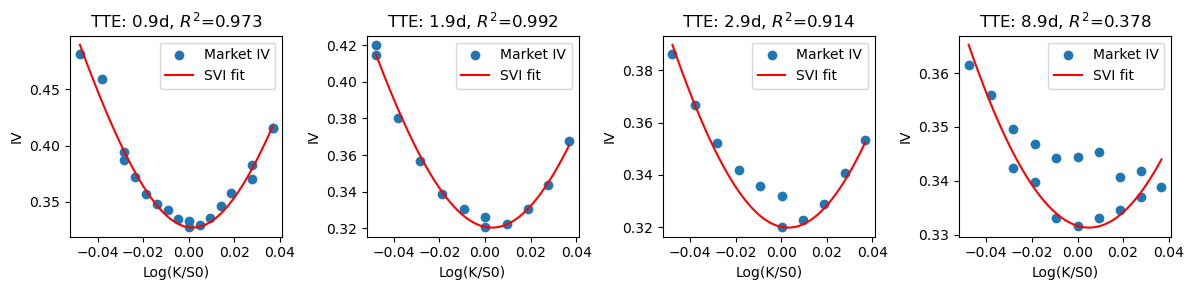

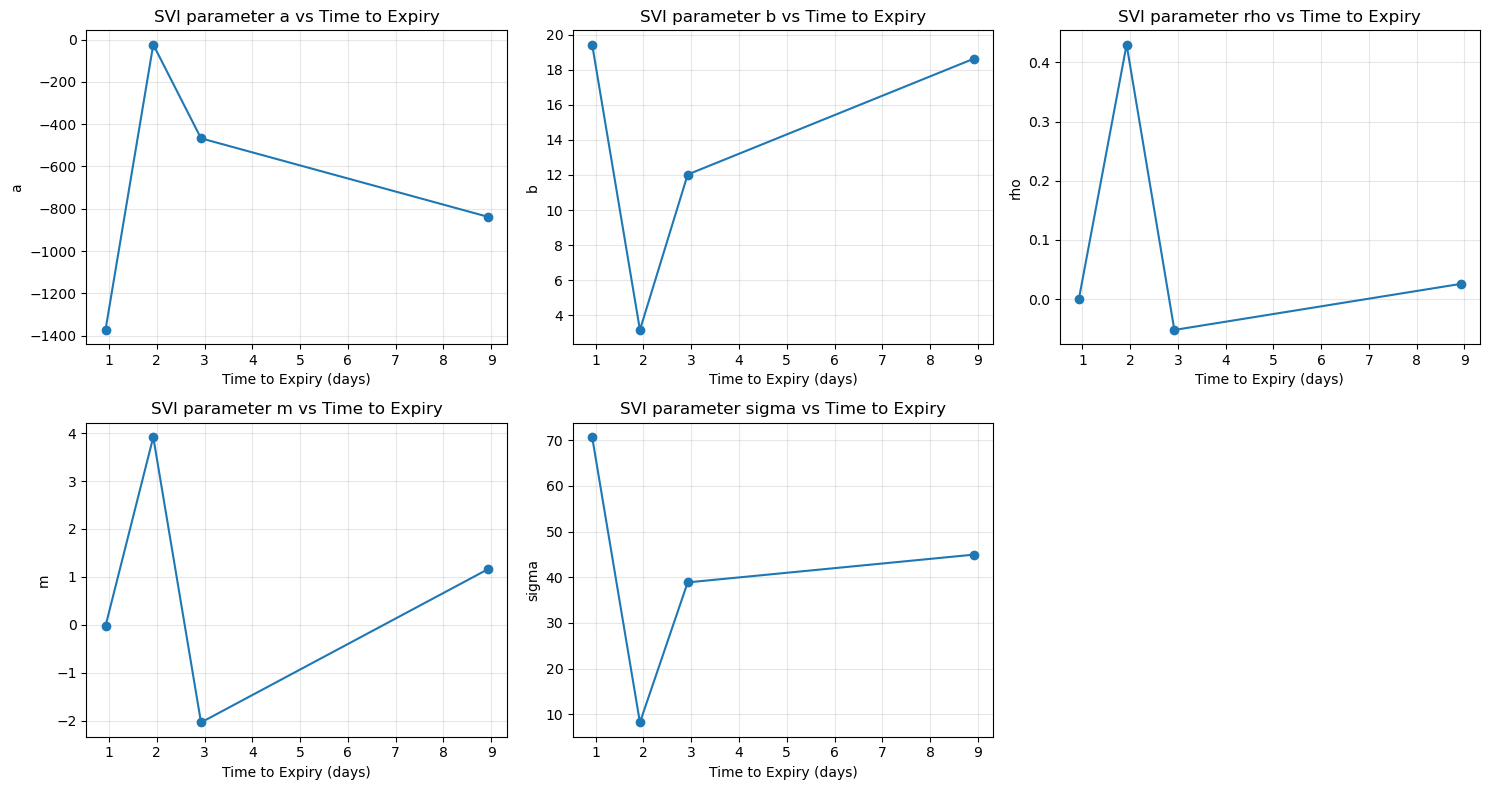

In [207]:
svi_params, Ts, maturity_dfs = analyze_vol_smile_SVI(df, S0, 9, 0.020, 5000, 1, 0)
plot_svi_params_vs_time(svi_params, Ts)